In [7]:
import pandas as pd
import random

names = ["Arun","Kavi","Ravi","Meena","Divya","John","Priya","Siva","Anu","Kumar"]

data = []

for i in range(250):
    student = {
        "Student_ID": i+1,
        "Name": random.choice(names),
        "Gender": random.choice(["Male","Female"]),
        "Department": random.choice(["CSE","IT","ECE"]),
        "Year": random.choice(["1st","2nd","3rd"]),
        "Maths": random.randint(40,100),
        "Science": random.randint(40,100),
        "English": random.randint(40,100),
        "Attendance": random.randint(50,100),
        "Internal": random.randint(0,25)
    }
    data.append(student)

df = pd.DataFrame(data)
df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal
0,1,Priya,Female,CSE,1st,99,61,58,53,2
1,2,Ravi,Male,IT,3rd,71,83,100,67,20
2,3,Kumar,Female,ECE,3rd,77,57,69,86,6
3,4,Priya,Female,CSE,3rd,79,86,80,98,18
4,5,Kumar,Female,IT,3rd,78,81,65,68,2


In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Student_ID  250 non-null    int64 
 1   Name        250 non-null    object
 2   Gender      250 non-null    object
 3   Department  250 non-null    object
 4   Year        250 non-null    object
 5   Maths       250 non-null    int64 
 6   Science     250 non-null    int64 
 7   English     250 non-null    int64 
 8   Attendance  250 non-null    int64 
 9   Internal    250 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 19.7+ KB
None
       Student_ID       Maths     Science     English  Attendance    Internal
count  250.000000  250.000000  250.000000  250.000000  250.000000  250.000000
mean   125.500000   71.600000   72.532000   70.512000   74.980000   12.556000
std     72.312977   17.221449   17.733892   18.179213   15.091541    7.867813
min      1.000000   40.000000   40.000000   40.

In [9]:
df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 75:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 50:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal,Total,Average,Grade
0,1,Priya,Female,CSE,1st,99,61,58,53,2,218,72.666667,B
1,2,Ravi,Male,IT,3rd,71,83,100,67,20,254,84.666667,A
2,3,Kumar,Female,ECE,3rd,77,57,69,86,6,203,67.666667,B
3,4,Priya,Female,CSE,3rd,79,86,80,98,18,245,81.666667,A
4,5,Kumar,Female,IT,3rd,78,81,65,68,2,224,74.666667,B


In [10]:
top_students = df.sort_values(by="Total", ascending=False).head(5)
print(top_students)

fail_students = df[df["Grade"] == "Fail"]
print(fail_students)

     Student_ID  Name  Gender Department Year  Maths  Science  English  \
74           75  Ravi    Male        CSE  3rd    100      100       96   
216         217  John    Male         IT  2nd    100       99       96   
94           95  Kavi  Female         IT  2nd     99       95       98   
44           45  Kavi    Male        ECE  3rd     99       87       96   
58           59  Kavi    Male        CSE  2nd     87       95       93   

     Attendance  Internal  Total    Average Grade  
74           81         5    296  98.666667     A  
216          93        16    295  98.333333     A  
94           91         1    292  97.333333     A  
44           85         2    282  94.000000     A  
58          100         4    275  91.666667     A  
     Student_ID Name  Gender Department Year  Maths  Science  English  \
141         142  Anu    Male        CSE  2nd     40       44       58   
183         184  Anu  Female         IT  2nd     43       55       45   

     Attendance  Intern

<Axes: xlabel='Department'>

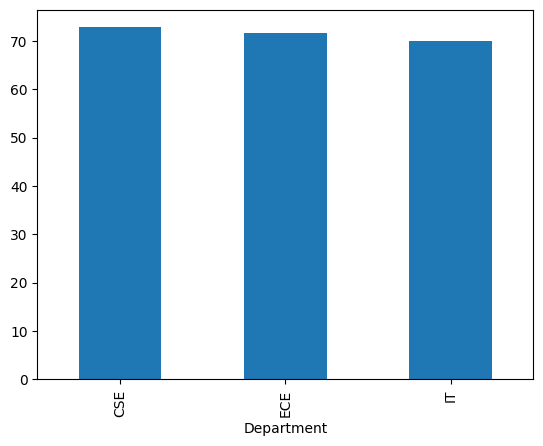

In [12]:
df.groupby("Department")["Average"].mean().plot(kind="bar")

<Axes: ylabel='count'>

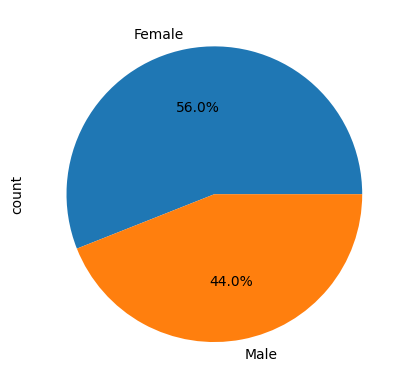

In [13]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")

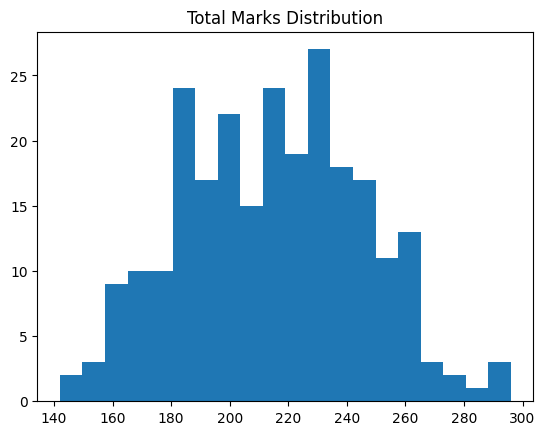

In [14]:
import matplotlib.pyplot as plt

plt.hist(df["Total"], bins=20)
plt.title("Total Marks Distribution")
plt.show()

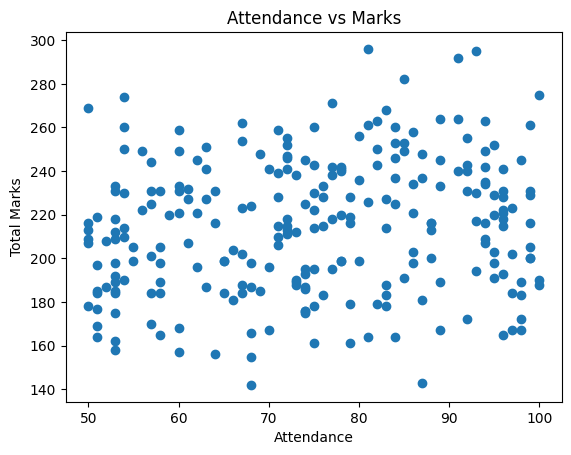

In [15]:
plt.scatter(df["Attendance"], df["Total"])
plt.xlabel("Attendance")
plt.ylabel("Total Marks")
plt.title("Attendance vs Marks")
plt.show()

In [16]:
print(df.groupby("Department")["Average"].mean())

Department
CSE    72.811111
ECE    71.696970
IT     70.040161
Name: Average, dtype: float64


In [17]:
print(df.groupby("Gender")["Average"].mean())

Gender
Female    71.519048
Male      71.584848
Name: Average, dtype: float64
